In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
%run Results_analysis_functions.ipynb

In [111]:
with open("rat8_results_across_sessions", "rb") as pkl_file:
    rat8_results_across_sessions= pickle.load(pkl_file)

with open("rat10_results_across_sessions", "rb") as pkl_file:
    rat10_results_across_sessions= pickle.load(pkl_file)

with open("rat11_results_across_sessions", "rb") as pkl_file:
    rat11_results_across_sessions= pickle.load(pkl_file)

with open("rat8_session_data_middle.pkl", "rb") as pkl_file:
    rat8_session_data= pickle.load(pkl_file)

with open("rat10_session_data_middle.pkl", "rb") as pkl_file:
    rat10_session_data= pickle.load(pkl_file)

with open("rat11_session_data_middle.pkl", "rb") as pkl_file:
    rat11_session_data= pickle.load(pkl_file)

In [112]:
all_results = {
    "rat8": rat8_results_across_sessions,
    "rat10": rat10_results_across_sessions,
    "rat11": rat11_results_across_sessions,
}

all_session_data ={
    "rat8": rat8_session_data,
    "rat10": rat10_session_data,
    "rat11": rat11_session_data,

}

## Visualising Results Across Sessions

In [113]:
means_first_all, means_second_all, differences_all, ratios, len_sequence = [], [], [], [], []
n_neurons = []
i = 0 
for rat, sessions in all_results.items():
    for session, data in sessions.items():
        # print(i,":", session)
        # i += 1
        means_first_all.append(data["means_first_middle"])
        means_second_all.append(data["means_second_middle"])  # Correct key for means_second_middle
        differences_all.append(data["difference"])
        significance.append(data["wilcoxon_p_in_session"])
        n_neurons.append(all_session_data[rat][session]["n_neurons"])
        
        if np.nanmean(data["difference"]) > 10:
            print("high diff",session, data["wilcoxon_p_in_session"], data["difference"])
        if(data["wilcoxon_p_in_session"] < 0.05 and np.nanmean(data["difference"]) > 0.5):
            print('significant', session, data["wilcoxon_p_in_session"], data["difference"] )

        if(session == "Rat11-20150331"):
            print(data["wilcoxon_p_in_session"], data["difference"])
        ratios.append(data["ratio_signif_neurons"])
        len_sequence.append(len(data["indices_significant"]))

significant Rat10-20140628 0.039794921875 0.889516972385517
high diff Rat10-20140708 0.07156508609119941 12.302543465462811
0.027707849358079864 0.007682037894197248


In [115]:
n_neurons_rat10= [31, 26, 12, 11, 9, 26, 9, 16, 14]
n_neurons_rat11 = [52, 41, 8, 2, 6, 24, 44, 50, 76, 15]
n_neurons_rat8 = [8, 28, 55, 55, 19]
np.mean([np.mean(n_neurons_rat10), np.mean(n_neurons_rat11), np.mean(n_neurons_rat8)])

22


In [118]:

threshold = 4
# Identify indices where the difference is less than or equal to the threshold

means_first_all = np.array(means_first_all)
means_second_all = np.array(means_second_all)
differences_all = np.array(differences_all)
valid_indices = np.where(differences_all < threshold)

# Filter the arrays to remove outliers
filtered_means_first_half = means_first_all[valid_indices]
filtered_means_second_half = means_second_all[valid_indices]

# Perform the Wilcoxon signed-rank test on the filtered data
wilcoxon_statistic, p_value = wilcoxon(filtered_means_first_half, filtered_means_second_half)

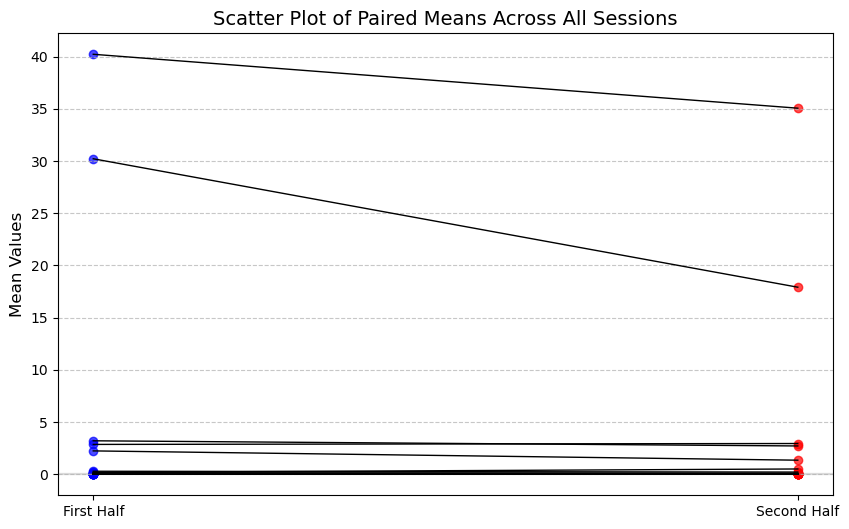

In [119]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Create the main scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
x_positions = [0,1]
ax.scatter(["First Half"] * len(means_first_all), means_first_all, color='blue', label="First Half Means", alpha=0.7)
ax.scatter(["Second Half"] * len(means_second_all), means_second_all, color='red', label="Second Half Means", alpha=0.7)
for i in range(len(means_first_all)):  # Connect the points for the same test run with a line
    ax.plot([x_positions[0], x_positions[1]], [means_first_all[i], means_second_all[i]], color='black', linewidth=1)
    
ax.set_title("Scatter Plot of Paired Means Across All Sessions", fontsize=14)
ax.set_ylabel("Mean Values", fontsize=12)
# ax.legend(fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Define the zoomed-in area
zoom_start, zoom_end = 0.0, 0.15 # Example y-range to zoom in

# Add a rectangle to highlight the zoomed-in area
ax.axhspan(zoom_start, zoom_end, color='gray', alpha=0.2, label='Zoomed Area')
plt.show()

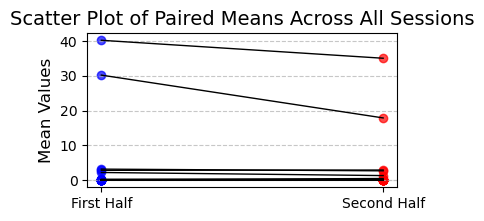

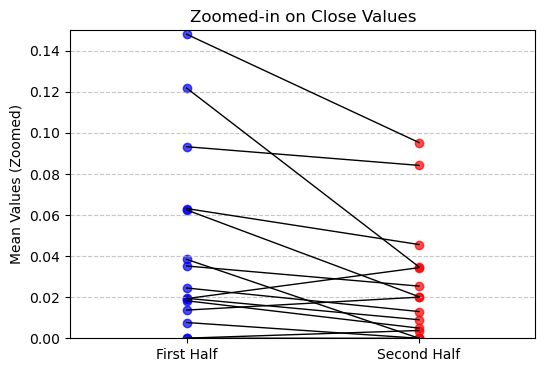

In [109]:
import matplotlib.pyplot as plt
import numpy as np

x_positions = [0, 1]  # X positions for First Half and Second Half

# Define the zoomed-in area
zoom_start, zoom_end = 0.0, 0.15  # Example y-range to zoom in

# Create the main scatter plot
fig, ax = plt.subplots(figsize=(4, 2))
ax.scatter(["First Half"] * len(means_first_all), means_first_all, color='blue', label="First Half Means", alpha=0.7)
ax.scatter(["Second Half"] * len(means_second_all), means_second_all, color='red', label="Second Half Means", alpha=0.7)
for i in range(len(means_first_all)):  # Connect the points for the same test run with a line
    ax.plot([x_positions[0], x_positions[1]], [means_first_all[i], means_second_all[i]], color='black', linewidth=1)

ax.set_title("Scatter Plot of Paired Means Across All Sessions", fontsize=14)
ax.set_ylabel("Mean Values", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Highlight the zoomed-in area
ax.axhspan(zoom_start, zoom_end, color='gray', alpha=0.2, label='Zoomed Area')

# Create a separate figure for the zoomed-in plot
fig_zoom, zoom_ax = plt.subplots(figsize=(6, 4))  # Adjust size for zoomed plot
zoom_ax.scatter(["First Half"] * len(means_first_all), means_first_all, color='blue', alpha=0.7, label="First Half")
zoom_ax.scatter(["Second Half"] * len(means_second_all), means_second_all, color='red', alpha=0.7, label="Second Half")
for i in range(len(means_first_all)):  # Connect the points for the same test run with a line
    zoom_ax.plot([x_positions[0], x_positions[1]], [means_first_all[i], means_second_all[i]], color='black', linewidth=1)

# Zoom settings
zoom_ax.set_xlim(-0.5, 1.5)  # Same x-axis range as main plot
zoom_ax.set_ylim(zoom_start, zoom_end)
zoom_ax.set_title("Zoomed-in on Close Values", fontsize=12)
zoom_ax.set_ylabel("Mean Values (Zoomed)", fontsize=10)
zoom_ax.grid(axis="y", linestyle="--", alpha=0.7)

# Show both plots
plt.savefig('Across_sessions_mean.svg')
plt.show()


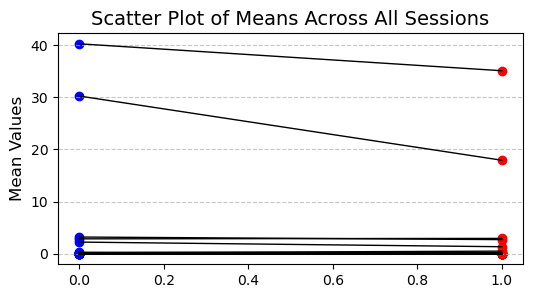

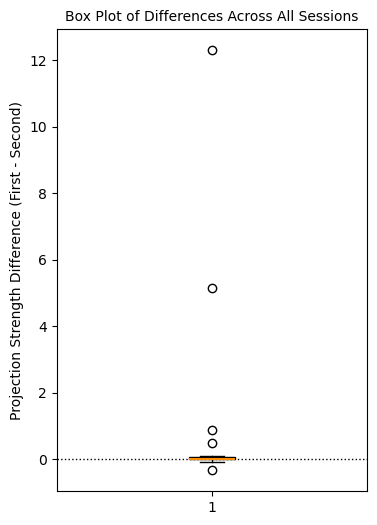

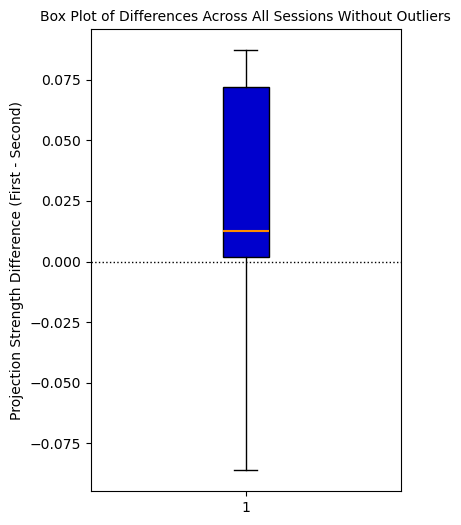

In [108]:
plt.figure(figsize=(6, 3))
x_positions = [0, 1]  # Use 0 for 'First Half' and 1 for 'Second Half'
for i in range(len(means_first_all)):
    plt.scatter(x_positions[0], means_first_all[i], color='blue', label='First Half' if i == 0 else "")  # Plot first half value
    plt.scatter(x_positions[1], means_second_all[i], color='red', label='Second Half' if i == 0 else "")  # Plot second half value
for i in range(len(means_first_all)):  # Connect the points for the same test run with a line
    plt.plot([x_positions[0], x_positions[1]], [means_first_all[i], means_second_all[i]], color='black', linewidth=1)
        
plt.title("Scatter Plot of Means Across All Sessions", fontsize=14)
plt.ylabel("Mean Values", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Means_Across_all_sessions.svg")

plt.figure(figsize=(4, 6))
plt.boxplot(differences_all, vert=True, patch_artist=True, boxprops=dict(facecolor="mediumblue", color="black"), medianprops=dict(color='darkorange', linewidth=1.5))
plt.axhline(0, color='black', linestyle=':', linewidth=1)  # Reference line at 0
plt.title("Box Plot of Differences Across All Sessions", fontsize=10)
plt.ylabel("Projection Strength Difference (First - Second)")
plt.savefig("Across_sessions_boxplot.svg")

plt.figure(figsize=(4, 6))
plt.boxplot(differences_all, vert=True, patch_artist=True, boxprops=dict(facecolor="mediumblue", color="black"), medianprops=dict(color='darkorange', linewidth=1.5), showfliers=False)
plt.axhline(0, color='black', linestyle=':', linewidth=1)  # Reference line at 0
plt.title("Box Plot of Differences Across All Sessions Without Outliers", fontsize=10)
plt.ylabel("Projection Strength Difference (First - Second)")
plt.savefig("Across_sessions_boxplot_zoom.svg")

### Normalized differences

[0.04228157127672523, -0.3292701623391604, 0.01752649632232202, 0.009094476590316827, -0.0037304504297555464, -0.006302556208235053, 0.009818135580929449, 0.0384633807065739, 0.889516972385517, 4.5637093829864916e-05, 5.1639900405290575, -0.086119354474532, 0.01043988381212363, 0.49442558025307193, 12.302543465462811, 0.08714814488349087, 0.013327851089862916, 0.07833065845872358, 0.011469291629279503, 0.05278340058810005, 0.007682037894197248, -0.015073652059158199]


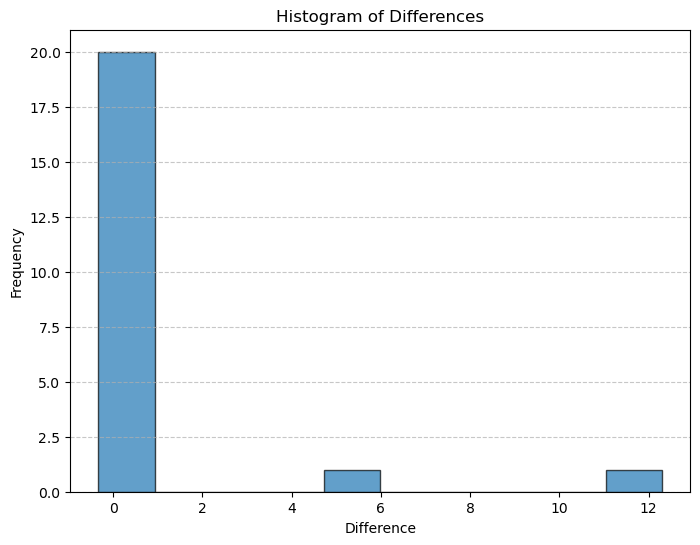

In [28]:
plt.figure(figsize=(8, 6))
print(differences_all)
plt.hist(differences_all, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Differences')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

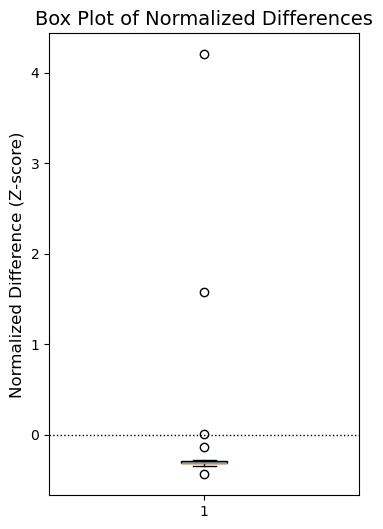

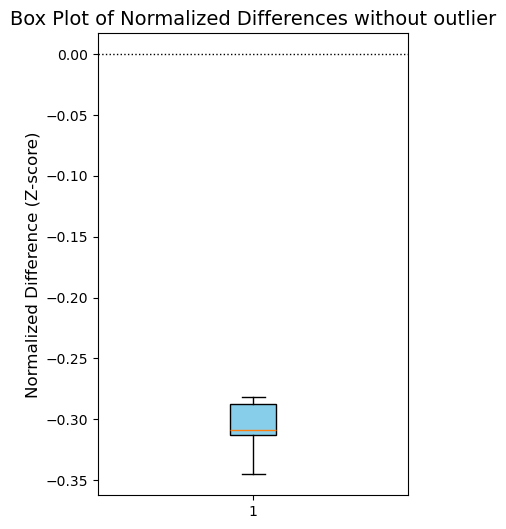

In [19]:
from scipy.stats import zscore
# Example data (replace with your actual data) # Example ratios of significant neurons

# Normalize the differences
normalized_differences = zscore(differences_all)  # Z-score normalization

# Box plot for normalized differences
plt.figure(figsize=(4, 6))
plt.boxplot(normalized_differences, vert=True, patch_artist=True, boxprops=dict(facecolor="skyblue", color="black"))
plt.axhline(0, color='black', linestyle=':', linewidth=1)  # Reference line at 0
plt.title("Box Plot of Normalized Differences", fontsize=14)
plt.ylabel("Normalized Difference (Z-score)", fontsize=12)
plt.show()

# Box plot for normalized differences
plt.figure(figsize=(4, 6))
plt.boxplot(normalized_differences, vert=True, patch_artist=True, boxprops=dict(facecolor="skyblue", color="black"), showfliers=False )
plt.axhline(0, color='black', linestyle=':', linewidth=1)  # Reference line at 0
plt.title("Box Plot of Normalized Differences without outlier", fontsize=14)
plt.ylabel("Normalized Difference (Z-score)", fontsize=12)
plt.show()

## Ratios of the significant neurons

[False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, True, True, True, False, True, True, False]
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


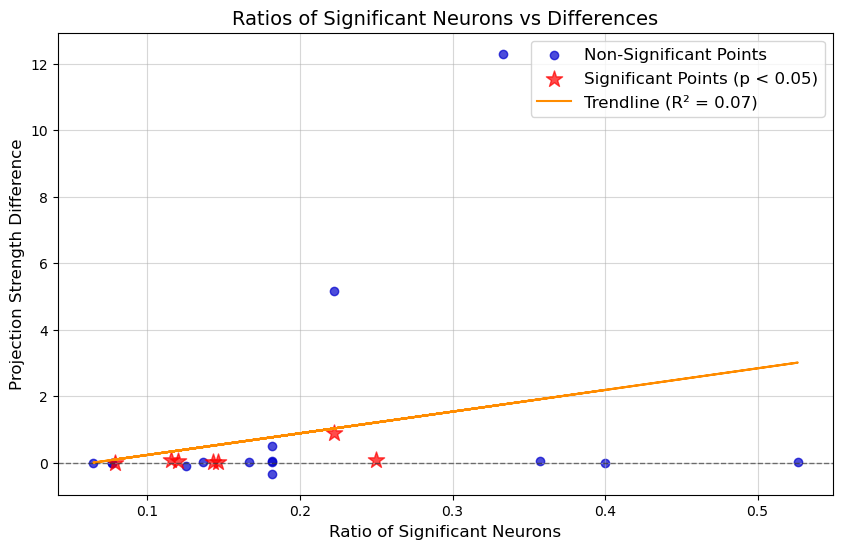

In [120]:
# Scatter plot of ratios of significant neurons vs differences
from scipy.stats import linregress

# Scatter plot

significance = [p < 0.05 for p in p_value_session]
print(significance)

plt.figure(figsize=(10, 6))

# Plot non-significant points
plt.scatter(
    np.array(ratios)[~np.array(significance)],  # Non-significant points
    np.array(differences_all)[~np.array(significance)],
    color='mediumblue',
    alpha=0.7,
    label="Non-Significant Points"
)

# Plot significant points with stars
plt.scatter(
    np.array(ratios)[np.array(significance)],  # Significant points
    np.array(differences_all)[np.array(significance)],
    color='red',
    alpha=0.7,
    marker='*',
    s=150,
    label="Significant Points (p < 0.05)"
)

# Compute and plot the linear trendline
slope, intercept, r_value, p_value, std_err = linregress(ratios, differences_all)
trendline = slope * np.array(ratios) + intercept
plt.plot(ratios, trendline, color='darkorange', label=f"Trendline (R² = {r_value**2:.2f})")

# Customize plot
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
plt.title("Ratios of Significant Neurons vs Differences", fontsize=14)
plt.xlabel("Ratio of Significant Neurons", fontsize=12)
plt.ylabel("Projection Strength Difference", fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.savefig("Projection_ratio_significant")
plt.show()



# plt.scatter(ratios, differences_all, color='mediumblue', alpha=0.7, label="_Data Points")

# # Compute and plot the linear trendline
# slope, intercept, r_value, p_value, std_err = linregress(ratios, differences_all)
# trendline = slope * np.array(ratios) + intercept
# plt.plot(ratios, trendline, color='red', label=f"Trendline (R² = {r_value**2:.2f})")

# # Customize plot
# plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)  # Reference line at y=0
# plt.title("Ratios of Significant Neurons vs Differences", fontsize=14)
# plt.xlabel("Ratio of Significant Neurons", fontsize=12)
# plt.ylabel("Projection Strength Difference", fontsize=12)
# plt.legend(fontsize=12)
# plt.grid(alpha=0.5)
# plt.show()


### Comparison within sessions


In [12]:
means_first_value, means_second_value, p_value_session = [], [], []
for rat, sessions in all_results.items():
    for session, data in sessions.items():
        means_first_value.append(data["mean_first_half_value"])
        means_second_value.append(data["mean_second_half_value"])
        p_value_session.append(data["wilcoxon_p_in_session"])
        

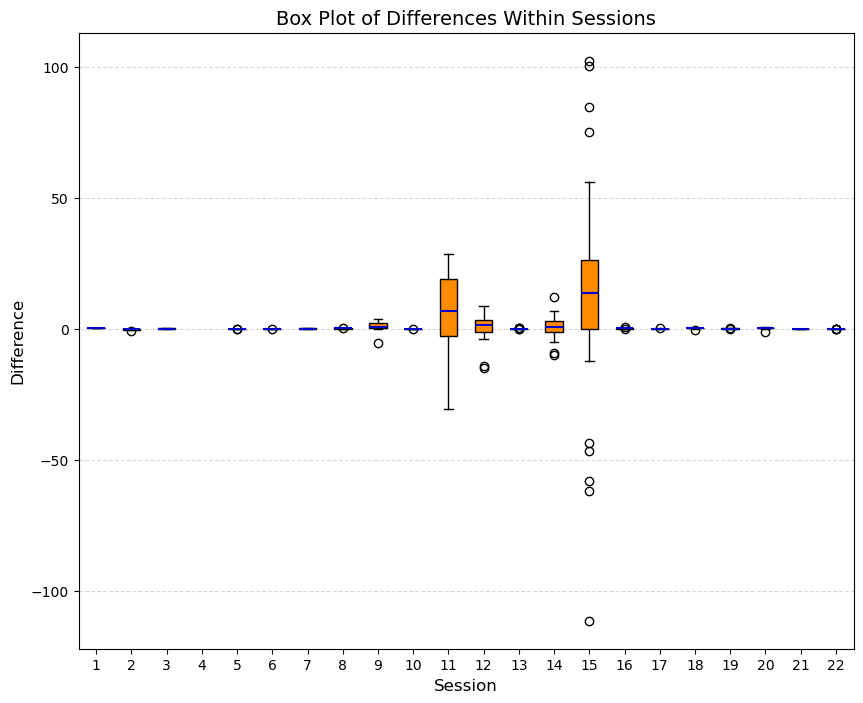

In [102]:

# Calculate differences for each session
session_differences = [first - second for first, second in zip(means_first_value, means_second_value)]
highlight_sessions = [8, 10, 11, 13, 14]
# Create box plots for each session
fig, ax = plt.subplots(figsize=(10, 8))
boxplot = ax.boxplot(session_differences, patch_artist=True, boxprops=dict(color="black"), medianprops=dict(color='mediumblue', linewidth=1.5))

for i, box in enumerate(boxplot['boxes']):
    if i not in highlight_sessions:
        box.set_facecolor("skyblue")  # Highlight color
    else:
        box.set_facecolor("darkorange")  # Default color

# Customize plot
ax.set_title("Box Plot of Differences Within Sessions", fontsize=14)
ax.set_xlabel("Session", fontsize=12)
ax.set_ylabel("Difference", fontsize=12)
ax.set_xticks(range(1, len(session_differences) + 1))  # Integer session IDs on x-axis
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.savefig('In_session_boxplot_difference.svg')
# Show the plot
plt.show()


### In session analysis: significance vs difference

Number of significant sessions: 7


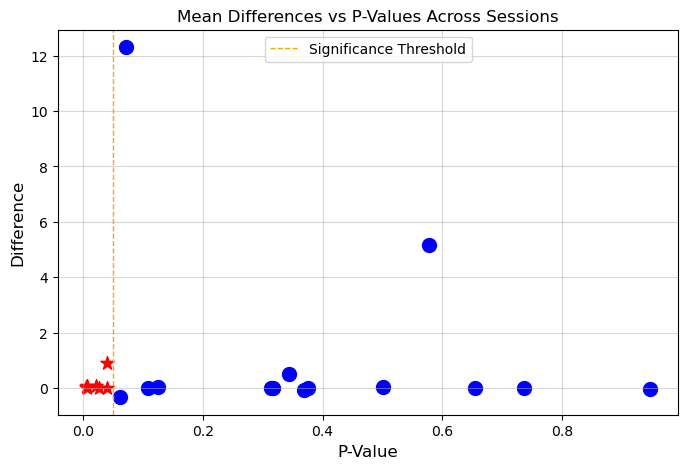

In [122]:
differences_all, p_value_session
# Example data (replace with your actual data)
significance = [p < 0.05 for p in p_value_session]  # Determine significance based on p-value
num_significant_sessions = sum(significance)
print(f"Number of significant sessions: {num_significant_sessions}")

# Plot
plt.figure(figsize=(8, 5))
for i in range(len(differences_all)):
    color = 'red' if significance[i] else 'blue'
    marker = '*' if significance[i] else 'o'
    plt.scatter(p_value_session[i], differences_all[i], color=color, label=f"_Session {i+1}" if i < 3 else None, marker=marker, s=100)

# Add significance threshold line
plt.axvline(0.05, color='orange', linestyle='--', linewidth=1, label="Significance Threshold")

# Customize the plot
plt.title("Mean Differences vs P-Values Across Sessions", fontsize=12)
plt.xlabel("P-Value", fontsize=12)
plt.ylabel("Difference", fontsize=12)
plt.legend(loc='upper center', fontsize=10)
plt.grid(alpha=0.5)
plt.show()
